# L16b Lab: Continuous LavaWorld with Deep Q-Learning
In lecture we solved the [LavaWorld grid problem](https://github.com/varnerlab/CHEME-5820-Lectures-Spring-2026) with tabular Q-learning: a robot picked one of four moves, the position was a discrete cell index, and the Q-table was just a states-by-actions matrix. 

That worked because the world was a $30\times 30$ grid, $900$ states. The moment we replace the integer position with a *continuous* position and add velocity, the state space becomes $\mathbb{R}^{4}$, the table blows up, and tabular Q-learning is dead. This is the curse of dimensionality, and it is exactly the regime DQN was built for.

__Problem statement.__ A [Figure-03 robot](https://www.figure.ai) lives on a continuous $L_{x}\times L_{y}$ board with state $\mathbf{s} = (x, y, v_{x}, v_{y})\in\mathbb{R}^{4}$. The robot has momentum and drag, and at each step it picks one of five thrust actions (+x, −x, +y, −y, or coast) which adds to the velocity, with Gaussian actuator noise. Lava pits are scattered across the board (terminal, large negative reward); a charger sits in one corner (terminal, large positive reward); every other step pays a small step cost. 

The goal is to learn a policy $\pi:\mathbb{R}^{4}\to\mathcal{A}$ that gets the robot to the charger from any starting state without driving into lava, using Deep Q-Learning with a replay buffer and a delayed target network.

> __Learning Objectives.__ After working through this notebook you should be able to:
>
> * __Build a continuous-state RL environment from scratch:__ Write a step function that integrates a noisy point-mass with drag and encodes terminal lava and charger conditions as a done flag. Confirm the function returns the next state, reward, and done flag consumed by the DQN update.
> * __Assemble and train a DQN agent:__ Construct a main Q-network and an identical target network, then wire them together with a circular replay buffer of experience tuples. Run the DQN training loop with a decaying ε-greedy schedule until the per-episode return curve and terminal-kind histogram show the agent reaching the charger.
> * __Read off what the agent learned:__ Run a batch of closed-loop rollouts under the trained greedy policy from a fixed set of sampled starts and overlay the trajectories on the board. Compare the trained agent against a uniformly-random baseline policy.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, which sets paths, loads external packages, and pulls in the DQN source files from `src/`:
* [`src/Types.jl`](src/Types.jl) defines `MyFluxNeuralNetworkModel`, `MyDQNLearningAgentModel`, and `MyDQNworldContextModel`.
* [`src/Factory.jl`](src/Factory.jl) defines `build(MyDQNworldContextModel; ...)` and `build(MyDQNLearningAgentModel; ...)`.
* [`src/Compute.jl`](src/Compute.jl) defines the environment step function `world`, the helpers `initial_state` / `_is_lava` / `_is_charger`, the DQN training loop `learn`, and the diagnostics `greedy_policy_field` and `rollout`.

In [13]:
include("Include.jl"); # load packages, src/ files, set random seed

  Activating project at `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b`
     Project No packages added to or removed from `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b/Project.toml`
    Manifest No packages added to or removed from `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b/Manifest.toml`


### Constants
We fix the board geometry, the robot dynamics, and the DQN hyperparameters up front. 

* __Board__: The board is $L_{x}\times L_{y}$ continuous units; lava pits and the charger are circles of fixed radius. 
* __Dynamics__: Each thrust action adds a small velocity kick to the corresponding component, the velocity is then damped by linear drag and clipped to a max speed, and the position is integrated forward with a fixed step size. 
* __Reward__: A small per-step cost, a large negative payout for hitting lava, a large positive payout for reaching the charger. 
* __DQN__: The DQN block sets the network width, the replay buffer geometry, and the training schedule called for by the L16a lecture.

Set the comment next to the constant to see its purpose, value, units, etc.

In [ ]:
# Board geometry --------------------------------------------------------------
LX              = 10.0f0    # board width  (continuous units)
LY              = 10.0f0    # board height (continuous units)
CHARGER_POS     = (8.5f0, 8.5f0)   # (x, y) center of the charging station (kept off the wall)
CHARGER_RADIUS  = 0.6f0
# LAVA_POS        = [(3.0f0, 3.0f0), (5.0f0, 6.0f0), (7.0f0, 2.0f0), (2.5f0, 7.5f0)]
LAVA_POS        = [(3.0f0, 3.0f0), (5.0f0, 6.0f0), (7.0f0, 2.0f0), (2.5f0, 7.5f0),(0.5f0, 6.0f0), (10.0f0, 10.0f0), (9.0f0, 5.0f0)]
LAVA_RADIUS     = 0.4f0

# Dynamics --------------------------------------------------------------------
THRUST          = 0.4f0     # Δv per directed thrust action
DRAG            = 0.15f0    # linear drag per step (∈ [0, 1])
DT              = 1.0f0     # integration step size
VMAX            = 1.5f0     # speed cap (per component)
ACT_NOISE       = 0.05f0    # actuator noise std

# Reward shape ----------------------------------------------------------------
STEP_COST       = -0.05f0   # per-step cost; encourages reaching the goal quickly
LAVA_REWARD     = -100.0f0  # terminal lava penalty
CHARGER_REWARD  = 100.0f0   # terminal charger reward
SHAPE_WEIGHT    = 1.0f0     # gain on potential-based distance-to-charger shaping (0 disables)

# DQN hyperparameters ---------------------------------------------------------
STATE_DIM       = 4         # (x, y, vx, vy)
HIDDEN          = 128       # hidden width of the Q-networks
BUFFER_SIZE     = 20_000    # capacity M of the circular replay buffer
WARMUP          = 1_000     # N_warm: no gradient updates until buffer ≥ this
MINIBATCH       = 64        # B: mini-batch size per gradient step
TARGET_SYNC     = 200       # C: copy main → target every TARGET_SYNC steps
DISCOUNT        = 0.99f0    # γ
LR              = 5.0f-4    # Adam learning rate
EPISODES        = 750       # number of training episodes (number of complete runs from start to terminal state {lava, charger})
MAX_STEPS_EP    = 400       # max steps per episode (timeout)
EPS_FLOOR       = 0.05f0    # floor on the ε-greedy exploration rate

# Cache -----------------------------------------------------------------------
CACHE_PATH      = joinpath(_ROOT, "data", "trained_agent.jld2")  # where the trained weights live
FORCE_RETRAIN   = false     # set true to retrain even if a cache exists
;

### Implementation: plotting helpers
Before any of the tasks, we define a small set of named plotting helpers that the figures throughout this notebook will reuse, so the per-task plot cells can stay short and focused on layout. These helpers reference the geometry constants from the cell above (`LX`, `LY`, `LAVA_POS`, `CHARGER_POS`, `LAVA_RADIUS`, `CHARGER_RADIUS`).

* `draw_board!(p; lava_alpha, charger_alpha)`: paints the lava pits (red) and charger (green) on an existing plot `p`.
* `term_color(sym)`: maps a rollout's terminal symbol (`:charger` / `:lava` / `:timeout`) to a plot color.
* `term_counts(rolls)` and `term_count_label(rolls)`: count and format the per-terminal-kind tallies across a vector of rollouts.
* `multi_trajplot(rolls; title)`: renders one panel, the board plus every trajectory in `rolls`, colored by outcome, with start dots and terminal stars.

Each helper has a docstring; you can call `?draw_board!` (etc.) at the REPL to read it.
___

In [15]:
# ----------------------------------------------------------------------------
# Plotting helpers (used in Task 1 and Task 3)
# ----------------------------------------------------------------------------

"""
    draw_board!(p; lava_alpha = 0.5, charger_alpha = 0.55,
                   lava_label = nothing, charger_label = nothing) -> p

Paint the LavaWorld board on an existing plot `p`: lava pits as red disks and the
charger as a green disk, using the geometry constants `LAVA_POS`, `LAVA_RADIUS`,
`CHARGER_POS`, and `CHARGER_RADIUS`.

Pass `lava_label` and/or `charger_label` to attach legend entries (only the first
lava disk is labeled, so the legend shows a single "lava" entry rather than one
per pit). Returns `p` so calls can be chained.
"""
function draw_board!(p; lava_alpha = 0.5, charger_alpha = 0.55,
                        lava_label = nothing, charger_label = nothing)
    θ = range(0, 2π; length = 60)

    # lava pits -
    for (i, (lx, ly)) ∈ enumerate(LAVA_POS)
        plot!(p, lx .+ LAVA_RADIUS .* cos.(θ), ly .+ LAVA_RADIUS .* sin.(θ);
            seriestype = :shape, fillcolor = :red, linecolor = :darkred,
            fillalpha = lava_alpha, label = (i == 1 ? lava_label : nothing))
    end

    # charger -
    cx, cy = CHARGER_POS
    plot!(p, cx .+ CHARGER_RADIUS .* cos.(θ), cy .+ CHARGER_RADIUS .* sin.(θ);
        seriestype = :shape, fillcolor = :green, linecolor = :darkgreen,
        fillalpha = charger_alpha, label = charger_label)

    return p
end

"""
    term_color(sym::Symbol) -> Symbol

Map a rollout's terminal kind to a plot color: `:charger → :seagreen`,
`:lava → :firebrick`, `:timeout → :gray40`.
"""
term_color(sym::Symbol) = sym == :charger ? :seagreen :
                           sym == :lava    ? :firebrick :
                                              :gray40

"""
    term_counts(rolls) -> NamedTuple

Tally the number of rollouts in `rolls` that ended at the charger, in lava, or by
timeout. Returns `(charger = ..., lava = ..., timeout = ...)`.
"""
term_counts(rolls) = (
    charger = count(r -> r.terminal == :charger, rolls),
    lava    = count(r -> r.terminal == :lava,    rolls),
    timeout = count(r -> r.terminal == :timeout, rolls),
)

"""
    term_count_label(rolls) -> String

One-line `"X charger · Y lava · Z timeout"` summary over a vector of rollouts. Used
as a panel sub-title in `multi_trajplot`.
"""
function term_count_label(rolls)
    c = term_counts(rolls)
    return "$(c.charger) charger · $(c.lava) lava · $(c.timeout) timeout"
end

"""
    multi_trajplot(rolls; title) -> Plot

Render a single panel: draw the LavaWorld board and overlay every trajectory in
`rolls`, color-coded by outcome (green = charger, red = lava, gray = timeout). Each
path gets a small black start dot and a colored terminal star.
"""
function multi_trajplot(rolls; title)
    p = plot(; xlim = (0, LX), ylim = (0, LY), aspect_ratio = :equal,
        xlabel = "x", ylabel = "y", title = title, titlefontsize = 11,
        bg = "gray95", background_color_outside = "white",
        framestyle = :box, legend = false)
    draw_board!(p)

    for r ∈ rolls
        c = term_color(r.terminal)
        plot!(p, r.xs, r.ys; lw = 1.0, alpha = 0.35, c = c, label = nothing)            # path
        scatter!(p, [r.xs[1]], [r.ys[1]];
            ms = 2, msw = 0, c = :black, alpha = 0.5, label = nothing)                  # start dot
        scatter!(p, [r.xs[end]], [r.ys[end]];
            ms = 4, msw = 0, c = c, marker = :star5, alpha = 0.8, label = nothing)      # terminal star
    end

    return p
end;

___

## Task 1: Build the continuous LavaWorld and look at it
In this task, we instantiate the world context, call [the `world(...)` function](src/Compute.jl) on a few hand-picked transitions, and render the board so we know what the agent will be navigating before we ask it to learn anything.

> __World dynamics model__
>
> Let $\mathbf{p}_{t} = (x_{t}, y_{t})\in\mathbb{R}^{2}$ denote the agent's position on the board and $\mathbf{v}_{t} = (v_{x,t}, v_{y,t})\in\mathbb{R}^{2}$ its velocity. The state vector stacks the two, $\mathbf{s}_{t} = (\mathbf{p}_{t}, \mathbf{v}_{t}) \in \mathbb{R}^{4}$, and the action $\mathbf{a}_{t} = (\Delta v_{x}, \Delta v_{y})\in\mathbb{R}^{2}$ is one of five thrust vectors (+x, −x, +y, −y, or coast). The dynamics are an Euler step of a noisy point-mass with linear drag:
> $$\mathbf{v}_{t+1} = (1 - \rho)\,\mathbf{v}_{t} + \mathbf{a}_{t} + \sigma\,\boldsymbol{\xi}_{t},\qquad \boldsymbol{\xi}_{t}\sim\mathcal{N}(0, I_{2}),$$
> where $\rho$ is the drag coefficient, $\sigma$ is the noise standard deviation, and $\boldsymbol{\xi}_{t}$ is a vector of independent standard normal random variables. We then componentwise-clip $\mathbf{v}_{t+1}$ to $[-v_{\max}, v_{\max}]^{2}$ to bound the speed, integrate the position via $\mathbf{p}_{t+1} = \mathbf{p}_{t} + \Delta t\,\mathbf{v}_{t+1}$, and finally clip $\mathbf{p}_{t+1}$ to the board, zeroing the offending velocity component when a wall is hit (absorbing walls). 
>
> This is *semi-implicit* Euler: we use $\mathbf{v}_{t+1}$ rather than $\mathbf{v}_{t}$ in the position update so that drag, the speed clip, and the thrust action all take effect on the same step.
>
> The reward $r_{t}$ and done flag $d_{t}$ are then given by the terminal conditions:
> $$ (r_{t}, d_{t}) = \begin{cases} (r_{\text{charger}}, 1), & \mathbf{p}_{t+1} \in \text{charger disk}, \\ (r_{\text{lava}}, 1), & \mathbf{p}_{t+1} \in \text{lava disk}, \\ (r_{\text{step}}, 0), & \text{otherwise}, \end{cases} $$
> where $r_{\text{step}} < 0$ is a small per-step cost (`STEP_COST`), $r_{\text{lava}} \ll 0$ is the terminal lava penalty (`LAVA_REWARD`), and $r_{\text{charger}} \gg 0$ is the terminal charger reward (`CHARGER_REWARD`); $d_{t} = 1$ marks a terminal transition that ends the episode. On non-terminal steps we also add a *potential-based* shaping bonus $w\,(d_{\text{old}} - d_{\text{new}})$, where $d$ is the L2 distance from the agent to the charger and $w$ is a small positive gain. 

The code block below stores the world parameters in [the `worldcontext::MyDQNworldContextModel` instance](src/Types.jl) for use in subsequent cells.

In [16]:
# Let's call the factory build function to build a context model -
worldcontext = build(MyDQNworldContextModel, 
(
        nrows           = Int(LY),                       # integer board height (used for internal sampling grids)
        ncols           = Int(LX),                       # integer board width  (used for internal sampling grids)
        lava            = LAVA_POS,                      # list of (x, y) lava-pit centers
        charger         = CHARGER_POS,                   # (x, y) center of the charger disk
        lava_radius     = LAVA_RADIUS,                   # radius of each lava disk (terminal region)
        charger_radius  = CHARGER_RADIUS,                # radius of the charger disk (terminal region)
        thrust          = THRUST,                        # Δv magnitude added per directed thrust action
        drag            = DRAG,                          # linear drag coefficient ρ ∈ [0, 1] per step
        dt              = DT,                            # integration step size Δt
        step_cost       = STEP_COST,                     # r_step: per-step reward on non-terminal transitions
        lava_reward     = LAVA_REWARD,                   # r_lava: terminal reward when the agent enters a lava disk
        charger_reward  = CHARGER_REWARD,                # r_charger: terminal reward when the agent enters the charger disk
        σ               = ACT_NOISE,                     # actuator-noise standard deviation in the velocity update
        vmax            = VMAX,                          # per-component speed cap |v_x|, |v_y| ≤ vmax
        Z               = Normal{Float32}(0.0f0, 1.0f0), # standard-normal distribution used to sample noise ξ_t
        shape_weight    = SHAPE_WEIGHT,                  # w: gain on the potential-based distance-to-charger shaping bonus (0 disables)
));

### Check the dynamics on three transitions
Let's hand [the `world(...)` function](src/Compute.jl) three states with three actions and see what we get. The first should land the robot in the charger and return done; the second should land it in lava with a large negative reward; the third should be a normal step that pays the per-step cost and is non-terminal.

In [17]:
let

    # Initialize -
    Random.seed!(7);
    # Pick starts so a single +y thrust step lands inside the intended disk.
    # With v₀ = 0 and a = (0, THRUST), semi-implicit Euler gives Δp ≈ (0, THRUST)
    # plus small actuator noise, so we offset the start by THRUST in −y.
    s_chg = Float32[CHARGER_POS[1], CHARGER_POS[2] - THRUST, 0.0f0, 0.0f0]   # → charger disk (radius 0.6)
    s_lav = Float32[LAVA_POS[1][1], LAVA_POS[1][2] - THRUST, 0.0f0, 0.0f0]   # → lava disk (radius 0.4)
    s_mid = Float32[5.0f0, 5.0f0, 0.0f0, 0.0f0]                              # interior, non-terminal step
    a_up  = Float32[0.0f0, THRUST]

    rows = NamedTuple{(:case, :x, :y, :vx, :vy, :reward, :done), Tuple{String, Float32, Float32, Float32, Float32, Float32, Bool}}[]
    for (label, s, a) ∈ (("step into charger", s_chg, a_up),
                          ("step into lava",    s_lav, a_up),
                          ("normal step",       s_mid, a_up))
        s′, r, d = world(s, a, worldcontext)
        push!(rows, (case = label, x = s′[1], y = s′[2], vx = s′[3], vy = s′[4],
                     reward = r, done = d))
    end
    
    # make a pretty table of the results -
    df = DataFrame(rows)
    pretty_table(df;
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact),
        formatters = [(v, i, j) -> v isa AbstractFloat ? round(v; sigdigits = 4) : v])
    df
end;

 ------------------- --------- --------- ---------- --------- --------- -------
               case         x         y         vx        vy    reward    done 
             String   Float32   Float32    Float32   Float32   Float32    Bool 
 ------------------- --------- --------- ---------- --------- --------- -------
  step into charger     8.478     8.599   -0.02184    0.4993     100.0    true
     step into lava     2.918     3.057   -0.08212    0.4565    -100.0    true
        normal step     4.963     5.395    -0.0369     0.395    0.1933   false
 ------------------- --------- --------- ---------- --------- --------- -------


### Visualize the board
We draw the board the agent will be working on: the rectangular play area, the lava pits are red disks, the charger as a green disk, and a small sample of starting states [drawn by `initial_state(...)` function](src/Compute.jl) to confirm that the rejection sampler avoids both the lava and the charger.

The code block below stores the sampled starting coordinates in `sx::Vector{Float32}` and `sy::Vector{Float32}` for use in subsequent cells.

In [18]:
sx,sy = let

    # Initialize -
    Random.seed!(11)
    number_of_starts = 300; # how many positions to sample for visualization
    samples = [initial_state(worldcontext) for _ ∈ 1:number_of_starts]
    sx = [s[1] for s ∈ samples] # x-coordinates of the sampled starts
    sy = [s[2] for s ∈ samples] # y-coordinates of the sampled starts

    (sx, sy) # return the sampled start coordinates for later use
end;

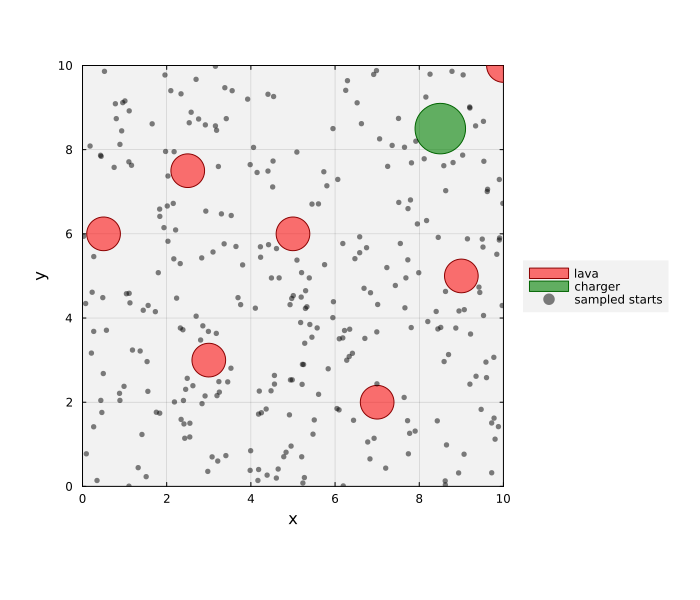

In [19]:
let

    # setup the plot -
    p = plot(; xlim = (0, LX), ylim = (0, LY), aspect_ratio = :equal,
        xlabel = "x", ylabel = "y",
        bg = "gray95", background_color_outside = "white", framestyle = :box,
        fg_legend = :transparent, legend = :outerright)

    # paint the lava pits + charger via the helper from the Setup section -
    draw_board!(p;
        lava_alpha    = 0.55,    # alpha for the red lava disks
        charger_alpha = 0.6,     # alpha for the green charger disk
        lava_label    = "lava",  # legend entry attached to the first lava disk
        charger_label = "charger") # legend entry on the charger disk

    # draw the sampled starts -
    scatter!(p, sx, sy; ms = 3, msw = 0, c = :black, alpha = 0.5,
        label = "sampled starts")

    plot(p; size = (700, 600),
        left_margin = 8Plots.mm, bottom_margin = 6Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
__What changes when we go from grid LavaWorld to continuous LavaWorld?__ In the tabular setting, the agent's state was a single integer $1,\ldots,n_{\text{states}}$ and a Q-table held one row per state. If we discretized $(x, y, v_{x}, v_{y})$ at $20$ levels per axis, how many states would the Q-table have? Now multiply by the number of actions $|\mathcal{A}| = 5$ to get the size of the full Q-table. 

Compare that to the parameter count of the small Q-network we are about to build (a Dense(4 → 128) + Dense(128 → 128) + Dense(128 → 5) MLP, count the weights and biases). Which one scales better as we increase the per-axis resolution from 20 to 50 to 100?

___

## Task 2: Assemble and train the DQN agent
In this task, we build the four moving parts of a DQN agent, the Q-network $Q_{\theta}$, i.e., our brain, a target Q-network $Q'_{\theta^{-}}$, a discrete action set $\mathcal{A}$, and a fixed-size circular replay buffer of experience tuples. We then run the DQN training loop on the world we built in Task 1.

> __Network architecture and what each piece is for.__
>
> The __main__ Q-network is a small MLP $Q_{\theta}:\mathbb{R}^{4}\to\mathbb{R}^{|\mathcal{A}|}$ with two hidden ReLU layers and a linear head producing one Q-value per action ($|\mathcal{A}| = 5$), where $\theta$ denotes the trainable weights and biases. The __target__ network $Q'_{\theta^{-}}$ has the *same* architecture, but its parameters $\theta^{-}$ are frozen between periodic syncs. Its only role is to produce, for each sampled experience $i$, a scalar $y_{i}\in\mathbb{R}$, the *bootstrap target*, that $Q_{\theta}(s_{i}, a_{i})$ is trained to match. 
> 
> __Hmmm, why two networks?__: The boostrap target $y_{i}$ is a *number*, not an action; it is our best current estimate of how good taking action $a_{i}$ from state $s_{i}$ is. We call this _bootstrap_ because we build that estimate from the network's *own* prediction at the next state $s^{\prime}_{i}$. Following the L16a lecture algorithm, the bootstrap target is given by:
> $$y_{i} = r_{i} + \gamma\,(1 - d_{i})\,\max_{a^{\prime}\in\mathcal{A}}\,[Q^{\prime}_{\theta^{-}}(s^{\prime}_{i})]_{a^{\prime}}.$$
> Each $i$ indexes an experience tuple $(s_{i}, a_{i}, r_{i}, s^{\prime}_{i}, d_{i})$ drawn from the replay buffer (state, action, reward, next state, done flag), and $\gamma\in[0, 1)$ is the discount factor (`DISCOUNT`). The factor $(1 - d_{i})$ zeros the bootstrap on terminal experiences ($d_{i} = 1$), so $y_{i} = r_{i}$ at the charger and at lava; this is why the world step function returns a done flag and our replay tuple stores it.

The code block below stores the main and target networks in `M::Chain` and `T::Chain`, and the learning agent [in `agent::MyDQNLearningAgentModel`](src/Types.jl) instance.

In [20]:
M, T, agent = let
    
    # initialize -
    Random.seed!(0xDA1A)
    
    # Fixed-scale normalization on the way into the Q-network. Without this,
    # x, y ∈ [0, LX]×[0, LY] hit a Dense(4 → 128, relu) with Glorot init and
    # saturate the activations; the Q-net then learns very slowly. Dividing
    # by the per-channel scale lands all four state coordinates in O(1).
    state_scale = Float32[LX, LY, VMAX, VMAX]
    normalize_state(x) = x ./ state_scale            # broadcasts over batch dim too

    # factory function to make a Q-network -
    make_qnet() = Chain(
        normalize_state,                              # non-trainable, no params
        Dense(STATE_DIM, HIDDEN, relu),
        Dense(HIDDEN,   HIDDEN, relu),
        Dense(HIDDEN,   5),                          # 5 = |𝒜|: +x, −x, +y, −y, coast
    )
    main = make_qnet(); # main network Q_θ with trainable parameters θ
    target = make_qnet(); # target network Q'_{θ⁻} with parameters θ⁻, initialized to θ
    Flux.loadmodel!(target, Flux.state(main))        # θ⁻ ← θ at initialization

    # assemble the agent -
    a = build(MyDQNLearningAgentModel, (
        mainnetwork      = main,        # main Q-network Q_θ; gradient steps are taken on its parameters θ
        targetnetwork    = target,      # target Q-network Q'_{θ⁻}; frozen between syncs, used to compute the bootstrap target y_i
        thrust           = THRUST,      # Δv magnitude per directed thrust action; sets the agent's action set 𝒜
        number_of_inputs = STATE_DIM,   # input dimension of the Q-networks (4 = (x, y, v_x, v_y))
    ))
    (main, target, a)
end;

### Train the agent (or load a cached one)
With the agent assembled, we can run the DQN training loop for a few hundred episodes of (up to) a couple hundred steps each, watch the per-episode data to confirm the agent is actually learning to reach the goal rather than just learning to avoid lava.

> __Training Problem.__
>
> For each episode we sample a fresh start state, explore the world up to a per-episode timeout, and at every step pick an action via a $t^{-1/3}$-decayed ε-greedy rule, execute it, and append the resulting experience tuple $(s_{i}, a_{i}, r_{i}, s^{\prime}_{i}, d_{i})$ to the replay buffer $\mathcal{D}$. 
>
> Once $|\mathcal{D}| \geq$ `WARMUP`, each step we draw a mini-batch $\mathcal{B}\subset\mathcal{D}$ of size $B$ and minimize the mean-squared *Bellman residual* between the main network's prediction at $(s_{i}, a_{i})$ and the bootstrap target $y_{i}$ given by:
> $$\mathcal{L}(\theta) \;=\; \frac{1}{B}\sum_{i \in \mathcal{B}}\Big([Q_{\theta}(s_{i})]_{a_{i}} \;-\; y_{i}\Big)^{2},\qquad y_{i} \;=\; r_{i} + \gamma\,(1 - d_{i})\,\max_{a^{\prime}\in\mathcal{A}}\,[Q^{\prime}_{\theta^{-}}(s^{\prime}_{i})]_{a^{\prime}}.$$
> The two halves of the residual look symmetric but are *not*. They use different states, different actions, and different networks:
>
> | piece                          | state    | action used                                              | network                                  |
> | ------------------------------ | -------- | -------------------------------------------------------- | ---------------------------------------- |
> | prediction $[Q_{\theta}(s_{i})]_{a_{i}}$ | $s_{i}$  | $a_{i}$ (the action **actually taken** in experience $i$) | main $Q_{\theta}$ (trainable)            |
> | target $y_{i}$                 | $s^{\prime}_{i}$ | $\arg\max_{a^{\prime}}$ (the action that **would be best** to take next) | target $Q^{\prime}_{\theta^{-}}$ (frozen) |
>
> __Why are the two sides different?__ On the left, we only know what reward we got for the action the agent actually took ($a_{i}$). We have no idea what would have happened if the agent had picked one of the other four actions at $s_{i}$, so we only update the Q-value for $a_{i}$, the other four Q-values at $s_{i}$ are left alone for now (they'll get updated later, from experiences where the agent happened to try them). On the right side, we use the max because $y_{i}$ is supposed to estimate the *best* the agent could do from the next state $s^{\prime}_{i}$, not just what it would do this time around.
>
> The target parameters $\theta^{-}$ are held *constant* during the gradient step, we do **not** differentiate through $Q^{\prime}_{\theta^{-}}$. These parameters are synced to $\theta$ only every `TARGET_SYNC` steps. We then take __one Adam step__ on $\theta$ with learning rate $\alpha$ = `LR`. If the experience is terminal, the episode ends early and we sample a new start.

__Caching.__ Training takes a few minutes; we write the trained weights and the per-episode history to the `trained_agent.jld2` file. The cell below loads the cache if it exists; set `FORCE_RETRAIN = true` in the constants cell (above) to retrain from scratch (e.g., after changing the network architecture or reward shaping). When training, the new weights are written back to the cache.

The code block below stores the trained agent (with replay buffer, when freshly trained) back into `agent::MyDQNLearningAgentModel` and the per-episode diagnostics in `history::NamedTuple` for use in subsequent cells. Training is done [by calling the `learn(...)` function](src/Compute.jl) with the world and world context as arguments.

In [21]:
agent, history = let
    
    # check: do we have a cached agent? If so, load it; if not, train and save it.
    if isfile(CACHE_PATH) && !FORCE_RETRAIN
        @info "loading cached agent" path=CACHE_PATH
        load_agent!(CACHE_PATH, agent)
    else

        # ok - when we get here, we DO NOT have a cached agent. We need to do the training.
        Random.seed!(2026) # set seed for reproducibility of training
        
        # We call the learn function to train the agent. 
        a, h = learn(agent, world;
            context              = worldcontext,   # the world context model (geometry, dynamics, reward shape)
            maxnumberofsteps     = MAX_STEPS_EP,   # per-episode step cap (timeout if not terminated by then)
            numberofepisodes     = EPISODES,       # total number of training episodes to run
            γ                    = DISCOUNT,       # discount factor γ ∈ [0, 1) used in the bootstrap target
            α                    = LR,             # Adam learning rate for the main Q-network
            maxreplaybuffersize  = BUFFER_SIZE,    # capacity M of the circular replay buffer
            warmupsize           = WARMUP,         # N_warm: no gradient updates until buffer holds ≥ this many experiences
            trainfreq            = 1,              # take a gradient step every this-many environment steps
            parameterupdatefreq  = TARGET_SYNC,    # C: copy main → target every C global steps
            minibatchsize        = MINIBATCH,      # B: experiences sampled per gradient step
            ε_floor              = EPS_FLOOR,      # lower bound on the t^(-1/3) ε-greedy exploration rate
            verbose              = true)           # print per-episode progress to the log
        
        # training is done! let's save the trained agent to disk for next time, and return it along with the training history.
        save_agent(CACHE_PATH, a, h)
        @info "saved trained agent" path=CACHE_PATH
        (a, h) # return the trained agent and the training history
    end
end;

┌ Info: DQN episode
│   episode = 1
│   return_ = -98.87
│   length = 8
│   terminal = lava
│   buffer = 8
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b/src/Compute.jl:224
┌ Info: DQN episode
│   episode = 75
│   return_ = -13.92
│   length = 200
│   terminal = timeout
│   buffer = 5903
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b/src/Compute.jl:224
┌ Info: DQN episode
│   episode = 150
│   return_ = -13.85
│   length = 200
│   terminal = timeout
│   buffer = 16593
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b/src/Compute.jl:224
┌ Info: DQN episode
│   episode = 225
│   return_ = -96.33
│   length = 11
│   terminal = lava
│   buffer = 20000
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring

### Reward curve and terminal-kind histogram
We pull two diagnostics out of the training history to check if our DQN is actually working. They're shown side-by-side below; the goal is to see *both* of these signals:

__Left panel, episode return rises over training.__ Each gray spike is the total return $G_{e} = \sum_{t=1}^{T_{e}}r_{t}$ of a single training episode, where $T_{e}$ is the length of episode $e$ (an episode ends early when the agent enters the charger or a lava disk, or at the timeout cap `MAX_STEPS_EP` if neither). The cyan curve is the right-aligned $w$-episode rolling mean of $G_{e}$, with $w = 25$:
$$\bar{G}_{e}^{(w)} \;=\; \frac{1}{\min(e, w)}\sum_{k = \max(1,\,e - w + 1)}^{e} G_{k}.$$
The $\min(e, w)$ in the denominator just handles the first $w-1$ episodes (before we have a full window, we average over however many episodes we *do* have). Two faint dashed reference lines mark the *worst case* (`LAVA_REWARD`) and *best case* (`CHARGER_REWARD`). 

__Right panel, the charger becomes the dominant terminal kind.__ We bin the episodes into groups of $10$ and plot the fraction of each bin that ended at the charger (green), in lava (red), or by timeout (gray). 

__What you should see:__ On the left, the cyan curve should climb from below zero (early episodes mostly time out or hit lava) to *near the charger reward* (most episodes end at the charger and get the big positive payout). On the right, we expect the green line to cross the red and gray lines and rise toward $1$, while the red and gray curves fall toward $0$.  

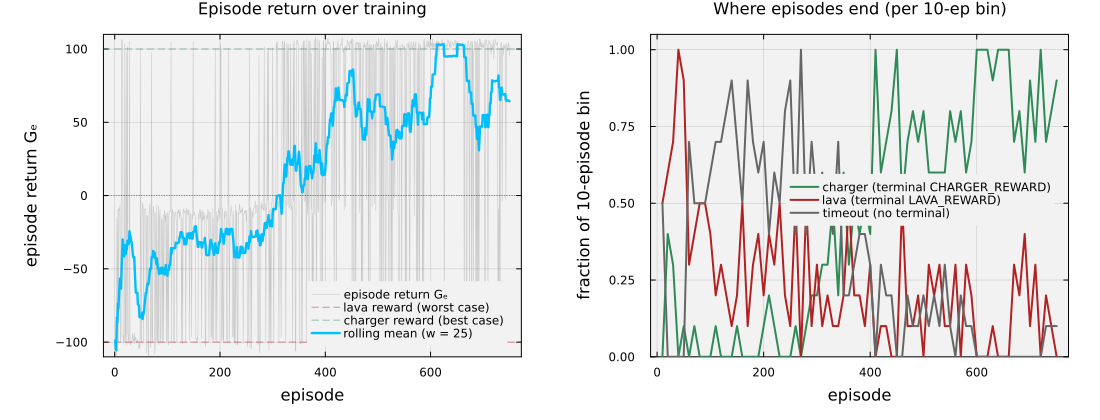

In [22]:
let

    # left panel: per-episode return + rolling mean, with reward-scale reference lines -
    G                = history.episode_returns                                                # per-episode returns G_e
    n                = length(G)                                                              # number of episodes trained
    rolling_window   = 25                                                                     # episodes per rolling-mean window
    rolling          = [mean(@view G[max(1, i - rolling_window + 1):i]) for i ∈ 1:n]          # right-aligned rolling mean

    p_curve = plot(1:n, G;
        c          = :gray,                                # raw episode return
        lw         = 0.6, alpha = 0.35,                    # dim so the rolling mean stands out
        label      = "episode return Gₑ",
        xlabel     = "episode",
        ylabel     = "episode return Gₑ",
        title      = "Episode return over training",
        titlefontsize = 11,
        ylim       = (LAVA_REWARD - 10, CHARGER_REWARD + 10),
        bg         = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :bottomright)

    # reward-scale anchors: lava (worst-case) and charger (best-case) -
    hline!(p_curve, [LAVA_REWARD];    c = :firebrick,  ls = :dash, lw = 0.8, alpha = 0.6, label = "lava reward (worst case)")
    hline!(p_curve, [CHARGER_REWARD]; c = :seagreen,   ls = :dash, lw = 0.8, alpha = 0.6, label = "charger reward (best case)")
    hline!(p_curve, [0.0];            c = :black,      ls = :dot,  lw = 0.7, alpha = 0.5, label = nothing)

    # rolling mean drawn last so it's on top of everything -
    plot!(p_curve, 1:n, rolling;
        c = :deepskyblue, lw = 2.4, label = "rolling mean (w = $rolling_window)")

    # right panel: fraction of each terminal kind in 10-episode bins -
    bin_size         = 10                                                                     # episodes per histogram bin
    n_bins           = cld(n, bin_size)                                                       # number of bins
    f_chg            = zeros(Float64, n_bins)                                                 # charger fraction per bin
    f_lava           = zeros(Float64, n_bins)                                                 # lava fraction per bin
    f_to             = zeros(Float64, n_bins)                                                 # timeout fraction per bin
    for i ∈ 1:n_bins
        lo    = (i - 1) * bin_size + 1
        hi    = min(i * bin_size, n)
        slice = history.terminal_kind[lo:hi]
        L     = length(slice)
        f_chg[i]  = count(==(:charger), slice) / L
        f_lava[i] = count(==(:lava),    slice) / L
        f_to[i]   = count(==(:timeout), slice) / L
    end
    bx = (1:n_bins) .* bin_size                                                               # bin's right-edge episode index

    p_term = plot(bx, f_chg;
        c          = :seagreen, lw = 2.0, label = "charger (terminal CHARGER_REWARD)",
        xlabel     = "episode",
        ylabel     = "fraction of $bin_size-episode bin",
        title      = "Where episodes end (per $bin_size-ep bin)",
        titlefontsize = 11,
        ylim       = (0, 1.05),
        bg         = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, legend = :right)
    plot!(p_term, bx, f_lava; c = :firebrick, lw = 2.0, label = "lava (terminal LAVA_REWARD)")
    plot!(p_term, bx, f_to;   c = :gray40,    lw = 2.0, label = "timeout (no terminal)")

    # combine -
    plot(p_curve, p_term; layout = (1, 2), size = (1100, 420),
        left_margin = 10Plots.mm, bottom_margin = 8Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about

__Read the two panels together.__ (a) Roughly when does the rolling mean cross zero, and what does that crossover correspond to in the terminal-kind plot? (b) Even after training, the lava fraction does not go all the way to zero, name two reasons rooted in what we built (the actuator noise and the ε-floor are not the only ones).

___

## Task 3: Visualize the learned policy and run a closed-loop rollout
In this task, we look at *what the agent learned* by closing the loop on the trained policy. We drop the agent into the world from *every* sampled start in `sx, sy` (the same starts plotted in Task 1) at zero velocity, run the rollout under the trained agent's greedy policy until the episode terminates or hits a step cap, and watch its trajectories. As a baseline we run the same procedure under a *uniformly-random* policy so we can see how much of the behavior is actually due to learning vs. luck.

### Closed-loop rollouts from every sampled start
Let's run a *batch* closed-loop test of the trained policy. For every initial position $(s_{x,i}, s_{y,i})$ sampled in Task 1, each at zero velocity, we run the trained agent under the greedy policy:
$$\pi_{\theta}(\mathbf{s}_{t}) \;=\; \arg\max_{a \in \mathcal{A}}\,[Q_{\theta}(\mathbf{s}_{t})]_{a},$$
where $\pi_{\theta}:\mathbb{R}^{4}\to\mathcal{A}$ is the deterministic policy induced by the trained main Q-network $Q_{\theta}$, $\mathbf{s}_{t} = (x_{t}, y_{t}, v_{x,t}, v_{y,t})$ is the current state, and $[Q_{\theta}(\mathbf{s}_{t})]_{a}$ is the entry of the Q-vector corresponding to action $a$. We step the world under $\pi_{\theta}$ until the rollout terminates (charger or lava) or hits a per-rollout step cap.

As a baseline we run the same procedure with a *uniformly-random* policy: at every step the action is drawn uniformly from $\mathcal{A}$ (the five thrusts), implemented as $\varepsilon$-greedy with $\varepsilon = 1$, so the Q-network is never consulted. The trained agent should reach the charger from the vast majority of starts; the uniformly-random baseline should mostly time out or fall into lava. We report counts of each terminal kind and overlay all the trajectories on the board in the next plot.

The trained agent's trajectories are stored in `trained_trajs::Vector{<:NamedTuple}` and the random baseline trajectories in `random_trajs::Vector{<:NamedTuple}` for use in the next plot.

In [23]:
trained_trajs, random_trajs = let

    # Initialize -
    Random.seed!(99)

    # Roll out from every sampled start (sx[i], sy[i]) at zero velocity, both
    # under the trained policy and under a uniformly-random baseline policy.
    rollout_max_steps = MAX_STEPS_EP                                       # cap each rollout at the training-time horizon
    starts = [Float32[sx[i], sy[i], 0.0f0, 0.0f0] for i ∈ eachindex(sx)]   # zero-velocity starts at every Task-1 sample

    # trained agent: greedy rollouts (argmax_a Q_θ(s, a)) from each start -
    trained = [rollout(agent, world;
            context   = worldcontext,        # the world context model (geometry, dynamics, reward shape)
            max_steps = rollout_max_steps,   # per-rollout step cap (timeout if not terminated by then)
            greedy    = true,                # take argmax-Q at every step (no exploration)
            s0        = s0)                  # initial state for this rollout
        for s0 ∈ starts]

    # uniformly-random baseline: ε-greedy with ε = 1 picks an action uniformly from 𝒜 at every step,
    # which means the random branch is taken every step and the Q-network is never consulted. We hand
    # `rollout(...)` the trained `agent` only because it needs *some* agent to access `agent.actions`;
    # the network itself is never evaluated, so this is genuinely a uniform random policy.
    Random.seed!(99)
    random = [rollout(agent, world;
            context   = worldcontext,        # same world context as the trained run
            max_steps = rollout_max_steps,   # same step cap
            greedy    = false,               # use the ε-random branch (don't take argmax-Q)
            ε         = 1.0f0,               # ε = 1 → every step samples a uniformly-random action from 𝒜
            s0        = s0)                  # initial state for this rollout
        for s0 ∈ starts]

    # summary: how many rollouts of each terminal kind, per agent?
    @info "batch rollout summary" n_starts = length(starts) trained = term_counts(trained) random = term_counts(random)

    (trained, random)
end;

┌ Info: batch rollout summary
│   n_starts = 300
│   trained = (charger = 53, lava = 23, timeout = 224)
│   random = (charger = 48, lava = 247, timeout = 5)
└ @ Main /Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Labs-Spring-2026/labs/week-16/L16b/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X34sZmlsZQ==.jl:33


### Trajectories on the board
Let's see what the trajectories look like. We overlay every rollout from every sampled start, one panel per agent. Each line is a single greedy trajectory; the color encodes the *outcome* of that rollout, green for charger, red for lava, gray for timeout. The terminal point is marked with a star in the same color. Start dots are plotted in black. 

The trained panel should be a green tangle of paths converging on the charger; the untrained panel should be a tangle of red and gray (lava deaths and timeouts).

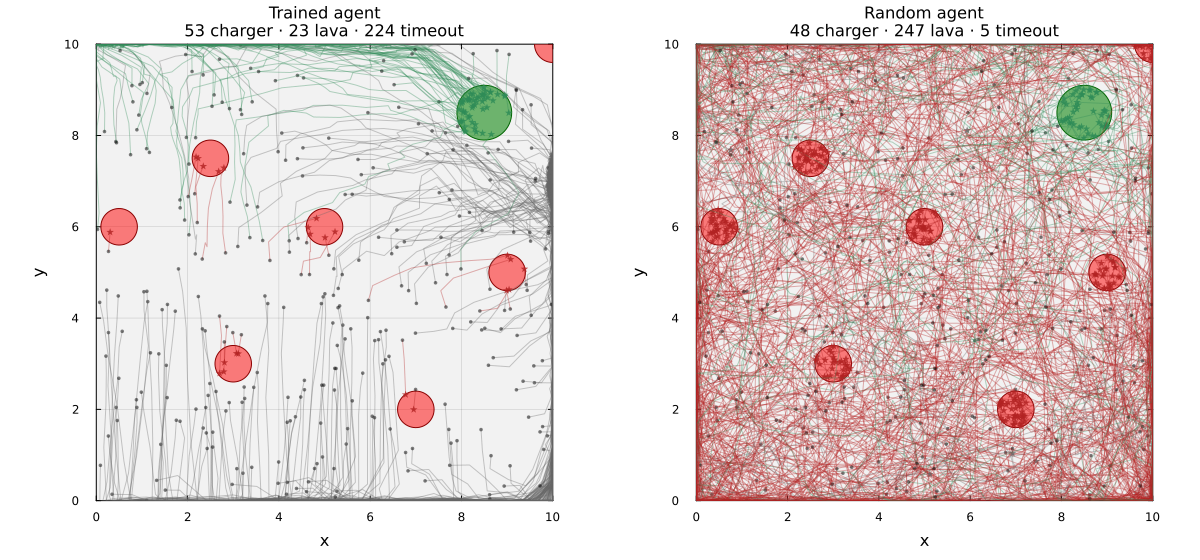

In [24]:
let
    # render one panel per agent using the multi_trajplot helper -
    p1 = multi_trajplot(trained_trajs; title = "Trained agent\n$(term_count_label(trained_trajs))")
    p2 = multi_trajplot(random_trajs;  title = "Random agent\n$(term_count_label(random_trajs))")

    # combine into a single side-by-side figure -
    plot(p1, p2; layout = (1, 2), size = (1200, 560),
        left_margin = 8Plots.mm, bottom_margin = 6Plots.mm,
        right_margin = 6Plots.mm, top_margin = 4Plots.mm)
end

### Things to think about
__What happens to our trained model if we add a new lava pit, i.e., what happens if the world the agent trained on is not the world it is deployed in?__ Suppose we drop a brand-new lava disk somewhere along one of the green flow lines in the trained agent's policy field (say, midway between $(0.5, 0.5)$ and the charger), *without* retraining $Q_{\theta}$. 

* (a) Will the trained policy avoid the new pit? Why or why not, what feature of the input would have to change for the network's output to change? 
* (b) Re-run the batch rollouts from `sx, sy` after adding the pit (you can edit `LAVA_POS` in the constants cell and rebuild `worldcontext`): how do you expect the `charger / lava / timeout` counts to shift? (c) This is the standard *distribution-shift* failure of model-free RL: the agent's policy is a function only of the state, with no notion of "the lava layout has changed." 

Name one architectural change (input features, network structure, or training procedure) that would let the same agent generalize to *any* lava layout drawn at deploy time, rather than memorizing the one it trained on.

___

## Summary
We took the discrete LavaWorld grid problem, replaced the discrete cell index with a continuous $\mathbb{R}^{4}$ state $(x, y, v_{x}, v_{y})$ that includes momentum, and trained a DQN agent to navigate it. 

> __Key Takeaways:__
>
> * **Continuous state kills the Q-table; a neural Q-function fixes it:** Going from a finite grid to a continuous four-dimensional state blows up the state space combinatorially, but the Q-network has a *fixed* parameter count and shares weights across the entire continuous board. The agent generalizes to states it never visited during training, and the policy field is smooth.
> * **The replay buffer and the target network are the two stabilizers, just as advertised:** Random mini-batches from a fixed-size buffer break the temporal correlation between consecutive transitions, while freezing the target parameters for a fixed number of steps before each sync keeps the bootstrap target from chasing the main parameters. The done flag in our replay tuples zeros the bootstrap on terminal transitions and makes the target value land on the actual reward at the charger and at lava.
> * **Reward shaping matters more than network architecture for small problems:** The choice of step cost, lava penalty, and charger reward is what determined whether the agent learns to seek the goal or just learns to stand still. Bumping the step cost further negative pushes the agent to be aggressive; making it too negative makes the agent prefer the lava as a faster way to end the episode.

Two natural extensions, both inside the framework we built:
* Replace uniform sampling from the replay buffer with *prioritized* experience replay (sample with probability proportional to $|y_{i} - Q_{\theta}(s_{i}, a_{i})|$); see whether the agent learns to avoid lava faster.
* Move from a discrete five-action thrust set to a continuous action space and switch the algorithm from DQN to DDPG; the same world step function still applies, only the actor/critic structure changes.

**That's a wrap for the semester! Thank you for the engagement, the questions, and now, go build something amazing!**
___